Project Part 3.2: Machine Learning Models Implementation - 05/31/2026 - aarsin4634

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "aarsin4634"

display(Markdown(f"### Project Part 3.2: Machine Learning Models Implementation - {todays_date} - {student_id}"))
display(Markdown("#### Prepare the Data (Catching ALL Missing Values)"))

# 1. Load the dataset
df = pd.read_csv('train.csv')
df_clean = df.copy()

# 2. Handle ALL Missing Data (The Fix)
# Find all numerical columns and fill blanks with the median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Find all text/categorical columns and fill blanks with 'None'
categorical_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna('None')

# 3. Basic Feature Engineering
df_clean['TotalSqFt'] = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']

# 4. Separate Features and Target
X = df_clean.drop(['Id', 'SalePrice'], axis=1)
y = df_clean['SalePrice']

# 5. Encode Categorical Variables
X_encoded = pd.get_dummies(X, drop_first=True)

# 6. Split the data FIRST (80% training, 20% testing) to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 7. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully cleaned, encoded, split, and scaled. Ready for modeling.")

### Project Part 3.2: Machine Learning Models Implementation - 2026-06-10 - aarsin4634

#### Prepare the Data (Catching ALL Missing Values)

Data successfully cleaned, encoded, split, and scaled. Ready for modeling.


C:\Users\Ren\AppData\Local\Temp\ipykernel_5248\1525978708.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


In [2]:
display(Markdown("#### Baseline Predictive Model (Linear Regression)"))

# Initialize and train a simple Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Evaluate the baseline model
base_mae = mean_absolute_error(y_test, y_pred_baseline)
base_mse = mean_squared_error(y_test, y_pred_baseline)
base_r2 = r2_score(y_test, y_pred_baseline)

print("--- Baseline Model Performance (Linear Regression) ---")
print(f"Mean Absolute Error (MAE): ${base_mae:,.2f}")
print(f"Mean Squared Error (MSE):  {base_mse:,.2f}")
print(f"R-squared (R2):            {base_r2:.4f}")

#### Baseline Predictive Model (Linear Regression)

--- Baseline Model Performance (Linear Regression) ---
Mean Absolute Error (MAE): $23,929.45
Mean Squared Error (MSE):  6,903,743,265.12
R-squared (R2):            0.0999


In [3]:
display(Markdown("#### Neural Network Implementation"))

# Define a simple Neural Network architecture
nn_model = Sequential()

# Input layer and first hidden layer (64 neurons, ReLU activation)
nn_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Second hidden layer (32 neurons, ReLU activation)
nn_model.add(Dense(32, activation='relu'))

# Output layer (1 neuron, Linear activation for predicting a continuous price)
nn_model.add(Dense(1, activation='linear'))

# Compile the model (Using Adam optimizer and Mean Squared Error for loss)
nn_model.compile(optimizer='adam', loss='mse')

print("Training the Neural Network for 50 epochs...")

# Train the network and save the history to monitor performance
history = nn_model.fit(
    X_train_scaled, 
    y_train, 
    validation_split=0.2, # Use 20% of training data to validate each epoch
    epochs=50, 
    batch_size=32, 
    verbose=0 # Set to 0 to keep the output clean
)

print("Neural Network training complete.")

#### Neural Network Implementation

C:\Users\Ren\anaconda3\envs\datascience\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the Neural Network for 50 epochs...
Neural Network training complete.


#### Neural Network Evaluation & Visualization

--- Neural Network Performance ---
Mean Absolute Error (MAE): $52,641.82
Mean Squared Error (MSE):  4,648,889,344.00
R-squared (R2):            0.3939


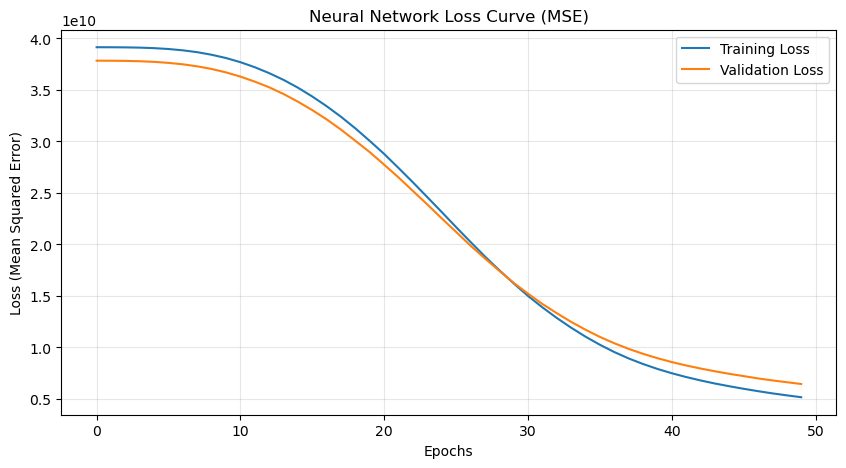

In [4]:
display(Markdown("#### Neural Network Evaluation & Visualization"))

# Make predictions with the Neural Network
y_pred_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()

# Evaluate the Neural Network
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

print("--- Neural Network Performance ---")
print(f"Mean Absolute Error (MAE): ${nn_mae:,.2f}")
print(f"Mean Squared Error (MSE):  {nn_mse:,.2f}")
print(f"R-squared (R2):            {nn_r2:.4f}")

# Plot the training vs. validation loss curve to check for underfitting/overfitting
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss Curve (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Scenario 1: The Remote Work Expansion (Demographic Shift): With remote work becoming permanent for many, buyers prioritize home office space over luxury finishes. We will simulate a 20% increase in GrLivArea (Living Area) but a 1-point drop in OverallQual to represent people buying larger, but slightly older/less updated homes to get the space they need.

Scenario 2: The Economic Squeeze (Economic Shift): Inflation and rising interest rates drastically reduce purchasing power. Homeowners defer maintenance, and buyers settle for less. We will simulate a widespread 2-point decrease in OverallQual across the entire test set.

Scenario 3: The Eco-Minimalist Trend (Environmental/Demographic): A cultural shift toward smaller, highly efficient, premium-built homes. We will simulate a 15% decrease in GrLivArea coupled with a 1.5-point increase in OverallQual.

In [9]:
display(Markdown("#### Scenario Analysis"))

# Helper function to process scenarios through our existing pipeline
def run_scenario(modified_df, scenario_name):
    # 1. Encode categorical variables exactly as before
    X_scen_encoded = pd.get_dummies(modified_df.drop(['Id', 'SalePrice'], axis=1), drop_first=True)
    
    # Ensure the scenario columns perfectly match the training columns (fill missing with 0)
    X_scen_aligned = X_scen_encoded.reindex(columns=X_train.columns, fill_value=0)
    
    # 2. Scale using the ALREADY FITTED scaler from Step 1
    X_scen_scaled = scaler.transform(X_scen_aligned)
    
    # 3. Predict using the Neural Network
    predictions = nn_model.predict(X_scen_scaled, verbose=0).flatten()
    
    # 4. Calculate the average predicted price for this scenario
    avg_price = np.mean(predictions)
    return avg_price

# Get the baseline average prediction from our existing test set
baseline_avg_price = np.mean(y_pred_nn)

# --- Scenario 1: Remote Work Expansion (+20% Size, -1 Quality) ---
df_scen1 = df_clean.copy()
df_scen1['GrLivArea'] = df_scen1['GrLivArea'] * 1.20
df_scen1['OverallQual'] = np.clip(df_scen1['OverallQual'] - 1, 1, 10) # Keep between 1-10
avg_s1 = run_scenario(df_scen1, "Scenario 1")

# --- Scenario 2: Economic Squeeze (-2 Quality) ---
df_scen2 = df_clean.copy()
df_scen2['OverallQual'] = np.clip(df_scen2['OverallQual'] - 2, 1, 10)
avg_s2 = run_scenario(df_scen2, "Scenario 2")

# --- Scenario 3: Eco-Minimalist (-15% Size, +1.5 Quality) ---
df_scen3 = df_clean.copy()
df_scen3['GrLivArea'] = df_scen3['GrLivArea'] * 0.85
df_scen3['OverallQual'] = np.clip(df_scen3['OverallQual'] + 1.5, 1, 10)
avg_s3 = run_scenario(df_scen3, "Scenario 3")

# Compile Results into a DataFrame
scenario_results = pd.DataFrame({
    'Scenario': ['Baseline (Current Market)', 'S1: Remote Work Expansion', 'S2: Economic Squeeze', 'S3: Eco-Minimalist Trend'],
    'Average Predicted Price': [baseline_avg_price, avg_s1, avg_s2, avg_s3]
})

scenario_results['% Change from Baseline'] = ((scenario_results['Average Predicted Price'] - baseline_avg_price) / baseline_avg_price) * 100

display(scenario_results.style.format({'Average Predicted Price': '${:,.2f}', '% Change from Baseline': '{:.2f}%'}))

# Export to Excel for PowerBI Dashboard update
scenario_results.to_excel('scenario_metrics.xlsx', index=False)

#### Scenario Analysis

,Scenario,Average Predicted Price,% Change from Baseline
0,Baseline (Current Market),"$138,810.59",0.00%
1,S1: Remote Work Expansion,"$139,581.52",0.56%
2,S2: Economic Squeeze,"$136,954.47",-1.34%
3,S3: Eco-Minimalist Trend,"$139,557.67",0.54%
